✅ 'korea_fs_data' 테이블에서 5584577건의 데이터를 가져왔습니다.
✅ root_hs_code=8408103000에 해당하는 224개 행을 불러왔습니다.
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(0, 1, 0), seasonal_order=(0, 1, 1, 4), AIC=1360.69


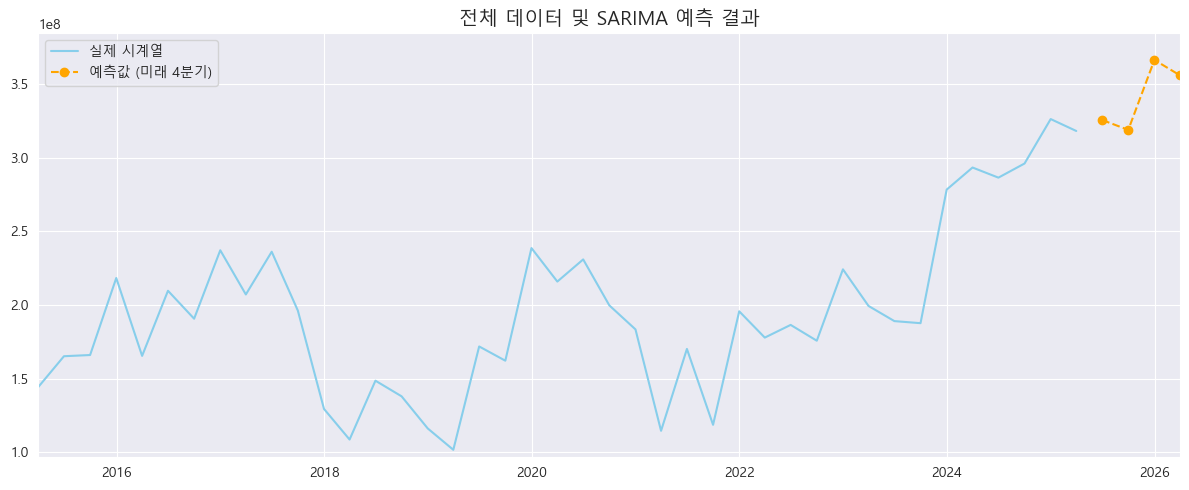


📈 미래 4분기 예측 결과:
2025-06-30    3.256444e+08
2025-09-30    3.189286e+08
2025-12-31    3.664338e+08
2026-03-31    3.559473e+08
Freq: QE-DEC, Name: predicted_mean, dtype: float64

📊 Ljung-Box Test (잔차 자기상관):
     lb_stat  lb_pvalue
4   1.633612   0.802739
8   2.549891   0.959364
12  4.055941   0.982406


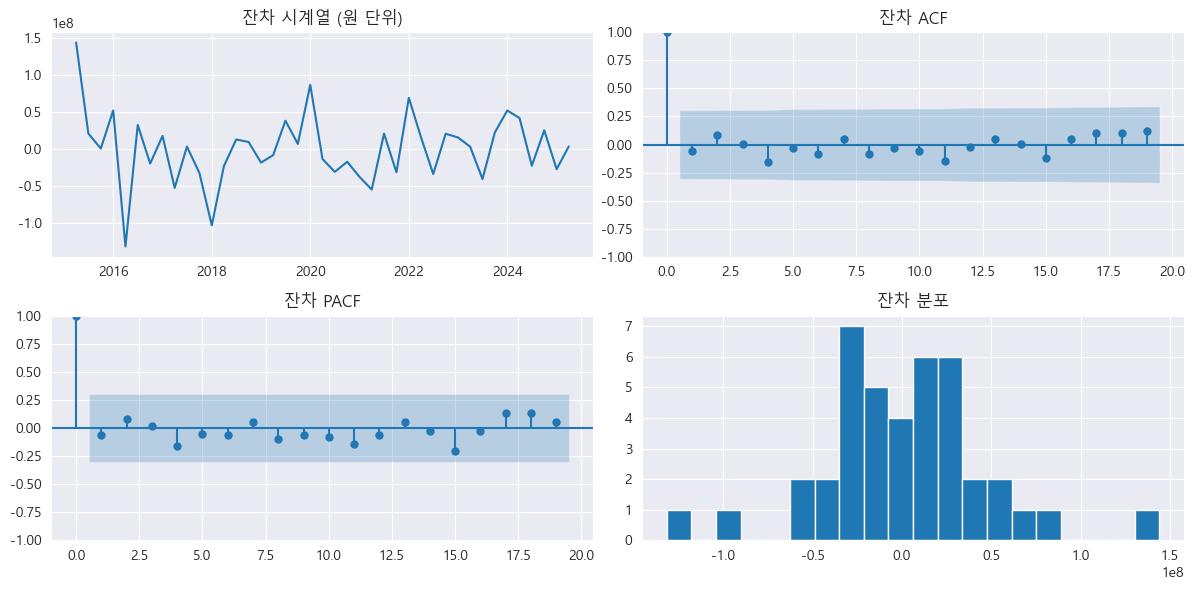

📎 외생변수 'exog_var' 포함
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(0, 1, 0), seasonal_order=(0, 1, 1, 4), AIC=1363.01


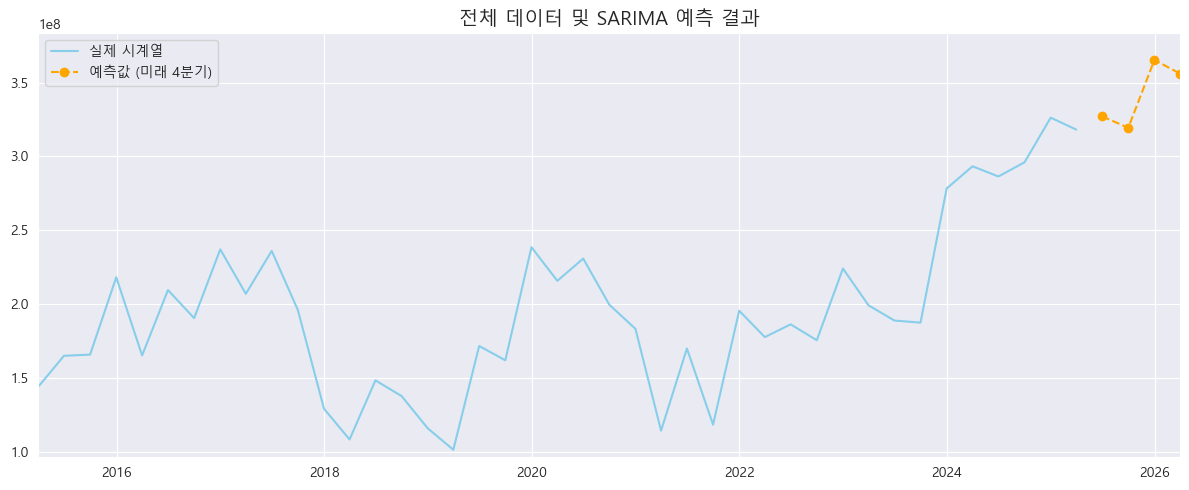


📈 미래 4분기 예측 결과:
2025-06-30    3.271558e+08
2025-09-30    3.194219e+08
2025-12-31    3.652941e+08
2026-03-31    3.560680e+08
Freq: QE-DEC, Name: predicted_mean, dtype: float64

📊 Ljung-Box Test (잔차 자기상관):
     lb_stat  lb_pvalue
4   1.485748   0.829163
8   2.713872   0.951012
12  4.296640   0.977469


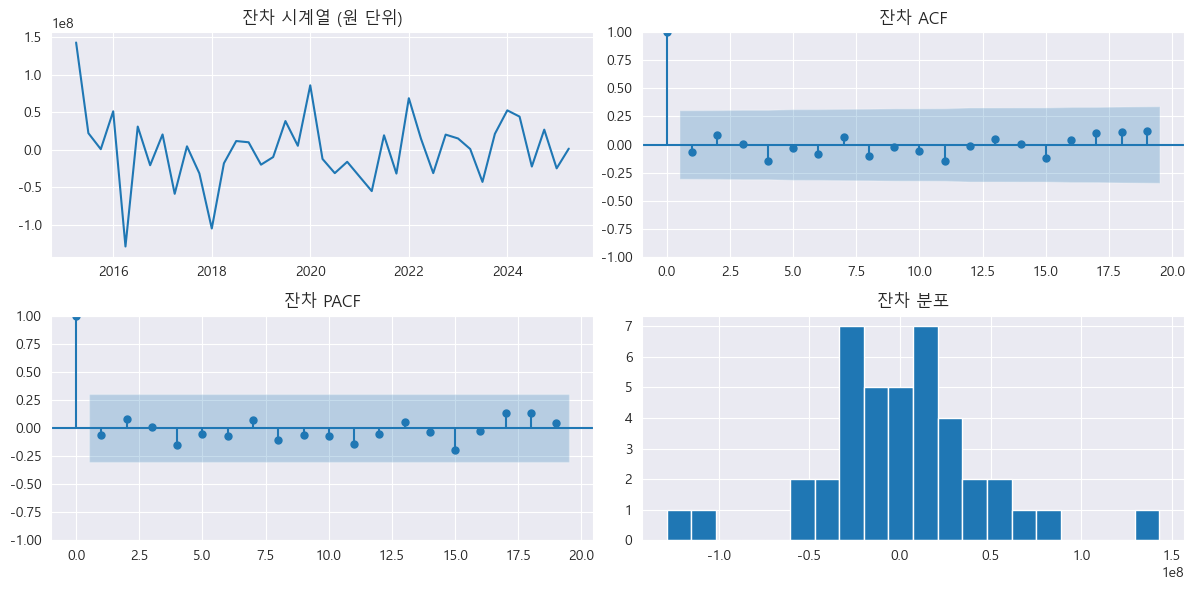

🔍 Grid Search 진행 중...
✅ 최적 모형: order=(0, 1, 0), seasonal_order=(1, 0, 0, 4), AIC=-25.80


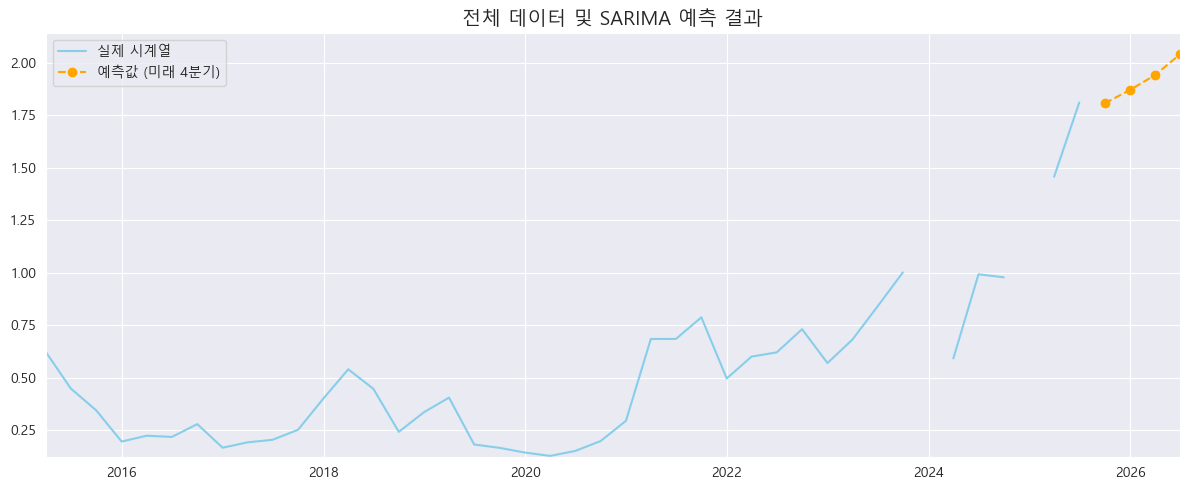


📈 미래 4분기 예측 결과:
2025-09-30    1.806675
2025-12-31    1.870793
2026-03-31    1.940911
2026-06-30    2.039859
Freq: QE-DEC, Name: predicted_mean, dtype: float64

📊 Ljung-Box Test (잔차 자기상관):
     lb_stat  lb_pvalue
4   3.324282   0.505094
8   4.887533   0.769526
12  8.251394   0.765189


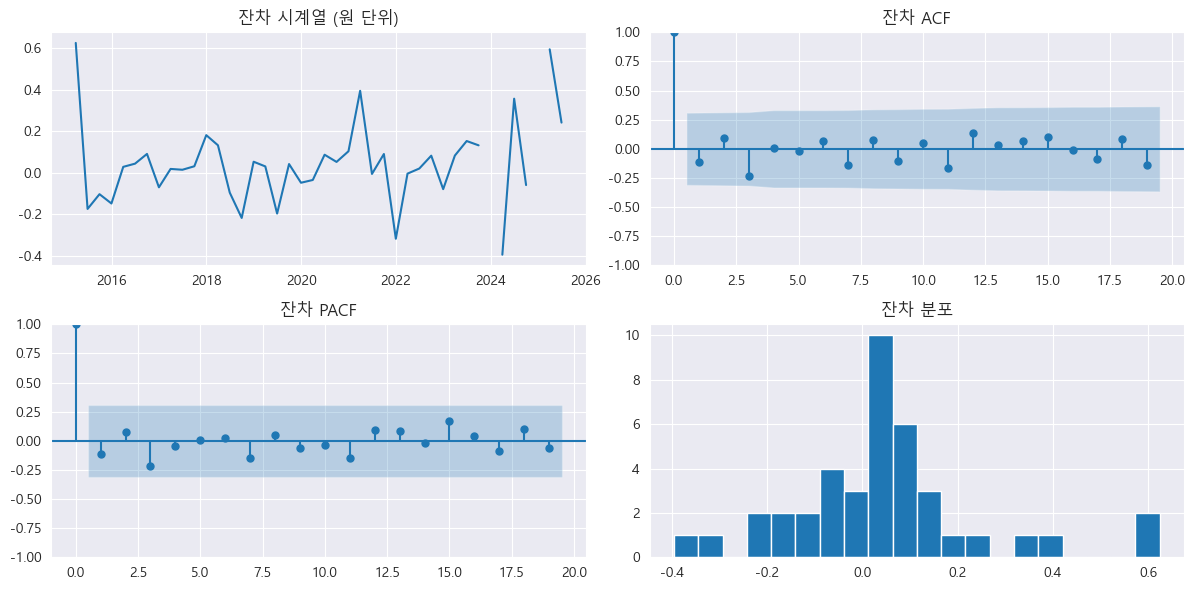

📎 외생변수 'exog_var' 포함
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(0, 1, 0), seasonal_order=(1, 0, 0, 4), AIC=-24.04


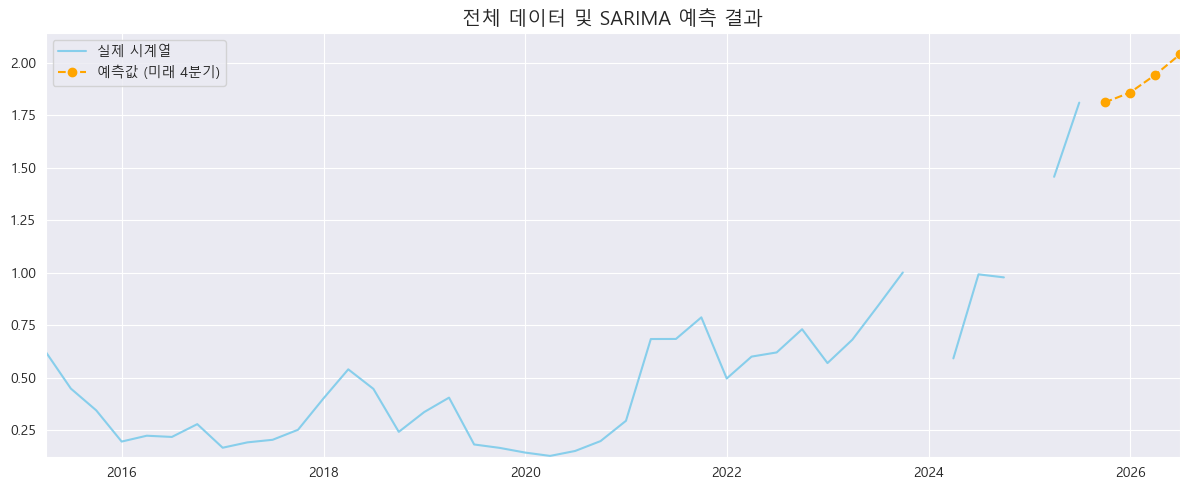


📈 미래 4분기 예측 결과:
2025-09-30    1.811664
2025-12-31    1.858764
2026-03-31    1.941829
2026-06-30    2.040434
Freq: QE-DEC, Name: predicted_mean, dtype: float64

📊 Ljung-Box Test (잔차 자기상관):
     lb_stat  lb_pvalue
4   3.156306   0.532017
8   4.478116   0.811618
12  8.193993   0.769793


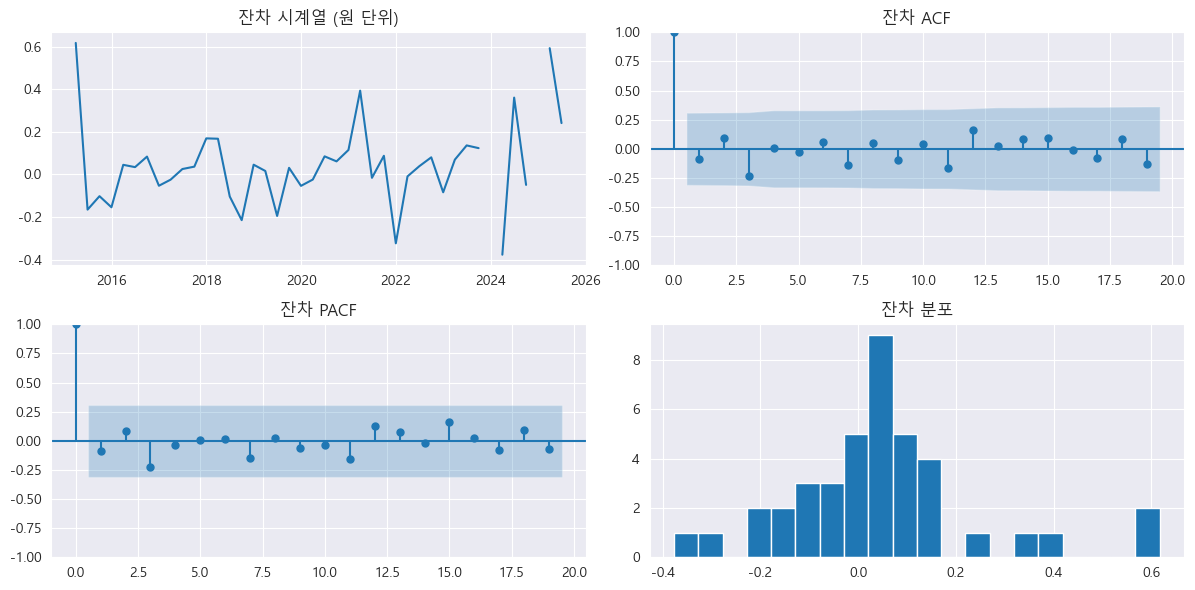

✅ root_hs_code=8408103000에 해당하는 224개 행을 불러왔습니다.
🔍 주기 설정: seasonal_period = 12
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(0, 1, 0), seasonal_order=(0, 0, 0, 12), AIC=-59.54
🔍 주기 설정: seasonal_period = 12
📎 외생변수 'exog_var' 포함
🔍 Grid Search 진행 중...
✅ 최적 모형: order=(0, 1, 0), seasonal_order=(0, 0, 0, 12), AIC=-57.58


15:52:28 - cmdstanpy - INFO - Chain [1] start processing
15:52:29 - cmdstanpy - INFO - Chain [1] done processing


예측 결과가 성공적으로 저장되었습니다. 총 360개 레코드
완료!


In [1]:
from DATA.stock_invest_function import *
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")
matplotlib.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def forecast_ratio_with_lstm_korea(ratio_df, window_size=60, forecast_days=31):
    """LSTM을 사용한 PSR 예측"""
    # 데이터 준비 및 스케일링
    series = ratio_df[['PSR']].copy()
    scaler = MinMaxScaler()
    scaled_series = scaler.fit_transform(series)

    # 시퀀스 데이터 생성
    def create_sequences(data, window_size=60):
        X, y = [], []
        for i in range(window_size, len(data)):
            X.append(data[i - window_size:i])
            y.append(data[i])
        return np.array(X), np.array(y)

    X_train, y_train = create_sequences(scaled_series, window_size)

    # LSTM 모델 구성 및 학습
    model = Sequential([
        LSTM(50, activation='relu', input_shape=(window_size, 1)),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

    # 미래 예측
    future = list(scaled_series[-window_size:].reshape(-1))
    predictions = []

    for _ in range(forecast_days):
        x_input = np.array(future[-window_size:]).reshape(1, window_size, 1)
        next_pred = model.predict(x_input, verbose=0)
        predictions.append(next_pred[0][0])
        future.append(next_pred[0][0])

    # 예측값 역변환
    forecasted_psr = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

    # 미래 날짜 생성
    last_date = ratio_df['date'].max()
    forecast_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=forecast_days)

    return pd.DataFrame({'date': forecast_dates, 'forecasted_PSR': forecasted_psr.flatten()})

def melt_forecast_df(df):
    """예측 결과를 long format으로 변환"""
    return df.melt(
        id_vars=['frequency', 'ticker', 'forecast_date'],
        var_name='indicator',
        value_name='value'
    )

# ===============================
# 설정 및 초기화
# ===============================
tic_name = 'A082740'
hs_code = '8408103000'
st_date = '2015-03-01'
end_date = '2025-03-31'
forecast_start_date = '2025-06-01'
forecast_end_date = '2026-06-01'
today_date = pd.to_datetime(datetime.today().date())

# DB 연결 정보
db_info = {
    'user': 'stox7412',
    'password': 'Apt106503!~',
    'host': get_db_host(),
    'port': '3307',
    'database': 'investar'
}

# SQLAlchemy 엔진 생성 (한 번만)
engine = create_engine(
    f"mysql+pymysql://{db_info['user']}:{db_info['password']}@{db_info['host']}:{db_info['port']}/{db_info['database']}?charset=utf8mb4"
)

# ===============================
# 데이터 로드 및 전처리
# ===============================

# 1. 재무 데이터 로드 (한 번만)
fs_df = fetch_table_data(db_info, "korea_fs_data")
fs_df['date'] = pd.to_datetime(fs_df['Date'] if 'Date' in fs_df.columns else fs_df['date'])
fs_df['value'] = pd.to_numeric(fs_df['value'], errors='coerce')

# 2. 매출액 데이터 준비
revenue_df = fs_df[
    (fs_df['indicator'] == '매출액(천원)') &
    (fs_df['symbol'] == tic_name)
].copy()

revenue_pivot = revenue_df.pivot_table(
    index='date', columns='symbol', values='value', aggfunc='first'
)
endog_df = revenue_pivot[[tic_name]].reset_index()

# 3. PSR 데이터 준비
psr_df = fs_df[
    (fs_df['indicator'] == '수정PSR(연율화)(배)') &
    (fs_df['symbol'] == tic_name)
].copy()

psr_pivot = psr_df.pivot_table(
    index='date', columns='symbol', values='value', aggfunc='first'
)
value_endog_df = psr_pivot[[tic_name]].reset_index()

# 4. 분기별 평균 PSR 계산
value_endog_df['date'] = pd.to_datetime(value_endog_df['date'])
quarterly_avg_df = value_endog_df.set_index('date').resample('Q').mean().reset_index()

# 5. 수출 데이터 로드
quarterly_sum_df = get_quarterly_export_forecast(db_info, hs_code)
quarterly_sum_df['date'] = pd.to_datetime(quarterly_sum_df['date_month'])
quarterly_sum_df = quarterly_sum_df.reset_index(drop=True)

# 6. 시가총액 데이터 로드 (SQL 최적화)
marketcap_query = f"""
SELECT date, value
FROM ks_listed_company_daily_marketcap
WHERE ticker = '{tic_name}' AND indicator = '시가총액'
ORDER BY date;
"""
df_market = pd.read_sql(marketcap_query, engine)
df_market['date'] = pd.to_datetime(df_market['date'])

# ===============================
# 예측 모델 실행
# ===============================

# 1. 매출액 예측
merged_revenue = merge_endog_exog_data(
    endog_df=endog_df,
    exog_df=quarterly_sum_df,
    endog_col=tic_name,
    exog_col='export_yoy_change',
    start_date=st_date,
    end_date=end_date,
)

revenue_forecasts_without_exog = forecast_future_4q_with_sarima(
    merged_revenue, date_col='date', value_col='endog_var',
    exog_col=None, use_log=False, fixed_variable=0
)
revenue_forecasts_with_exog = forecast_future_4q_with_sarima(
    merged_revenue, date_col='date', value_col='endog_var',
    exog_col='exog_var', use_log=False, fixed_variable=0
)

# 2. PSR 예측 (분기별)
merged_value_exog = merge_endog_exog_data(
    endog_df=quarterly_avg_df,
    exog_df=quarterly_sum_df,
    endog_col=tic_name,
    exog_col='export_yoy_change',
    start_date=st_date,
    end_date=forecast_end_date
)

ratio_forecast_result_without_exog = forecast_future_4q_with_sarima(
    merged_value_exog, date_col='date', value_col='endog_var',
    exog_col=None, use_log=False, fixed_variable=0
)
ratio_forecast_result_with_exog = forecast_future_4q_with_sarima(
    merged_value_exog, date_col='date', value_col='endog_var',
    exog_col='exog_var', use_log=False, fixed_variable=0
)

# ===============================
# 일별 PSR 계산 및 예측
# ===============================

# TTM 매출액 계산 (벡터화)
revenue_df_sorted = revenue_df.sort_values('date')
revenue_df_sorted['TTM_Revenue'] = revenue_df_sorted['value'].rolling(window=4).sum()

# 시가총액과 TTM 매출액 병합
df_daily_psr = pd.merge(
    df_market,
    revenue_df_sorted[['date', 'TTM_Revenue']],
    on='date',
    how='left'
).ffill()

df_daily_psr['PSR'] = df_daily_psr['value'] / (df_daily_psr['TTM_Revenue'] * 1000)
df_daily_psr = df_daily_psr.dropna(subset=['PSR'])

# 월별 PSR 데이터 준비
df_monthly_psr = df_daily_psr.set_index('date').resample('M').last().reset_index()

# 수출 데이터와 병합 (월별)
target_export_df = load_forecast_by_hscode(db_info, hs_code, table_name='korea_monthly_trade_data_forecast')
target_export_df['date'] = pd.to_datetime(target_export_df['date'])
target_export_df = target_export_df.drop_duplicates(subset=['date'])

merged_monthly_df = pd.merge(
    df_monthly_psr[['date', 'PSR']],
    target_export_df[['date', 'final_expDlr_yoy']],
    on='date',
    how='left'
).rename(columns={
    'PSR': 'endog_var',
    'final_expDlr_yoy': 'exog_var'
})

# 월별 PSR 예측
ratio_forecast_monthly_result_without_exog = forecast_future_with_sarima(
    merged_monthly_df, freq='M', forecast_steps=12,
    date_col='date', value_col='endog_var', exog_col=None,
    use_log=False, fixed_variable=0
)
ratio_forecast_monthly_result_with_exog = forecast_future_with_sarima(
    merged_monthly_df, freq='M', forecast_steps=12,
    date_col='date', value_col='endog_var', exog_col='exog_var',
    use_log=False, fixed_variable=0
)

# LSTM 예측
lstm_forecast = forecast_ratio_with_lstm_korea(df_daily_psr)

# Prophet 예측
df_prophet = df_daily_psr[['date', 'PSR']].rename(columns={'date': 'ds', 'PSR': 'y'})
model = Prophet(daily_seasonality=True, yearly_seasonality=True)
model.fit(df_prophet)

future = model.make_future_dataframe(periods=90)
prophet_forecast = model.predict(future)

# ===============================
# 결과 통합 및 저장
# ===============================

# 예측 결과 이름 변경 및 통합
revenue_forecasts_with_exog = revenue_forecasts_with_exog.rename('revenue_with_exog')
revenue_forecasts_without_exog = revenue_forecasts_without_exog.rename('revenue_without_exog')

# 총 매출액 계산
total_revenue_with_exog = revenue_forecasts_with_exog.sum()
total_revenue_without_exog = revenue_forecasts_without_exog.sum()

# 가치 예측 결과 준비
value_forecast_with_exog = ratio_forecast_result_with_exog.rename('PSR_quarter_with_exog')
value_forecast_without_exog = ratio_forecast_result_without_exog.rename('PSR_quarter_without_exog')

value_forecast_monthly_with_exog = ratio_forecast_monthly_result_with_exog.rename(
    columns={'forecast': 'PSR_monthly_with_exog'}
)
value_forecast_monthly_without_exog = ratio_forecast_monthly_result_without_exog.rename(
    columns={'forecast': 'PSR_monthly_without_exog'}
)

lstm_forecast = lstm_forecast.rename(columns={'forecasted_PSR': 'PSR_daily_lstm'})
prophet_forecast_resize = prophet_forecast[['ds', 'trend']].rename(
    columns={'ds': 'date', 'trend': 'PSR_daily_prophet'}
)

# 장기 예측 결과 통합
longterm_value_forecasts = pd.concat([
    value_forecast_with_exog, value_forecast_without_exog,
    revenue_forecasts_with_exog, revenue_forecasts_without_exog
], axis=1)

longterm_value_forecasts['revenue_with_exog_sum'] = total_revenue_with_exog
longterm_value_forecasts['revenue_without_exog_sum'] = total_revenue_without_exog
longterm_value_forecasts['value_with_exog'] = (
    longterm_value_forecasts['PSR_quarter_with_exog'] *
    longterm_value_forecasts['revenue_with_exog_sum']
)
longterm_value_forecasts['value_without_exog'] = (
    longterm_value_forecasts['PSR_quarter_without_exog'] *
    longterm_value_forecasts['revenue_without_exog_sum']
)

# 중기 예측 결과 통합
midterm_value_forecasts = pd.concat([
    value_forecast_monthly_with_exog, value_forecast_monthly_without_exog
], axis=1)

midterm_value_forecasts['revenue_with_exog'] = total_revenue_with_exog
midterm_value_forecasts['revenue_without_exog'] = total_revenue_without_exog
midterm_value_forecasts['value_with_exog'] = (
    midterm_value_forecasts['PSR_monthly_with_exog'] *
    midterm_value_forecasts['revenue_with_exog']
)
midterm_value_forecasts['value_without_exog'] = (
    midterm_value_forecasts['PSR_monthly_without_exog'] *
    midterm_value_forecasts['revenue_without_exog']
)

# 단기 예측 결과 통합
lstm_forecast_indexed = lstm_forecast.set_index('date')
prophet_forecast_resize_indexed = prophet_forecast_resize.set_index('date')

shortterm_value_forecasts = pd.concat([
    lstm_forecast_indexed, prophet_forecast_resize_indexed
], axis=1, join='inner')

# 단기 가치 계산
shortterm_value_forecasts['revenue_with_exog'] = total_revenue_with_exog
shortterm_value_forecasts['revenue_without_exog'] = total_revenue_without_exog

value_columns = {
    'lstm_value_with_exog': ('PSR_daily_lstm', 'revenue_with_exog'),
    'lstm_value_without_exog': ('PSR_daily_lstm', 'revenue_without_exog'),
    'prophet_value_with_exog': ('PSR_daily_prophet', 'revenue_with_exog'),
    'prophet_value_without_exog': ('PSR_daily_prophet', 'revenue_without_exog')
}

for col_name, (psr_col, revenue_col) in value_columns.items():
    shortterm_value_forecasts[col_name] = (
        shortterm_value_forecasts[psr_col] * shortterm_value_forecasts[revenue_col]
    )

# 메타데이터 추가
for df, freq in [(longterm_value_forecasts, 'Q'),
                 (midterm_value_forecasts, 'M'),
                 (shortterm_value_forecasts, 'D')]:
    df['frequency'] = freq
    df['ticker'] = tic_name
    df['forecast_date'] = today_date

# Long format으로 변환 및 통합
combined_long_format = pd.concat([
    melt_forecast_df(longterm_value_forecasts),
    melt_forecast_df(midterm_value_forecasts),
    melt_forecast_df(shortterm_value_forecasts)
], axis=0, ignore_index=True)

# DB에 저장
combined_long_format.to_sql(
    name='KR_valuation_result_data_V1',
    con=engine,
    if_exists='replace',
    index=False
)

print(f"예측 결과가 성공적으로 저장되었습니다. 총 {len(combined_long_format)}개 레코드")
print("완료!")

In [3]:
combined_long_format

,frequency,ticker,forecast_date,indicator,value
0,Q,A082740,2025-08-18,PSR_quarter_with_exog,NaN
1,Q,A082740,2025-08-18,PSR_quarter_with_exog,1.811664e+00
2,Q,A082740,2025-08-18,PSR_quarter_with_exog,1.858764e+00
3,Q,A082740,2025-08-18,PSR_quarter_with_exog,1.941829e+00
4,Q,A082740,2025-08-18,PSR_quarter_with_exog,2.040434e+00
...,...,...,...,...,...
355,D,A082740,2025-08-18,prophet_value_without_exog,3.059567e+09
356,D,A082740,2025-08-18,prophet_value_without_exog,3.063453e+09
357,D,A082740,2025-08-18,prophet_value_without_exog,3.067338e+09
358,D,A082740,2025-08-18,prophet_value_without_exog,3.071223e+09
